In [3]:
#Import Libraries & Load Data

import pandas as pd

df = pd.read_csv('/content/Crop_recommendation.csv')
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
#Basic Inspection

print(df.shape)
print(df.columns)
df.info()
df.describe()

(2200, 8)
Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [5]:
#Check Missing Values

df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [6]:
df = df.dropna()  # or use fillna()

In [7]:
#Check Duplicate Rows

df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop_duplicates()

In [9]:
#Encode Target Variable (Crop Label)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

In [10]:
dict(zip(le.classes_, le.transform(le.classes_)))

{'apple': np.int64(0),
 'banana': np.int64(1),
 'blackgram': np.int64(2),
 'chickpea': np.int64(3),
 'coconut': np.int64(4),
 'coffee': np.int64(5),
 'cotton': np.int64(6),
 'grapes': np.int64(7),
 'jute': np.int64(8),
 'kidneybeans': np.int64(9),
 'lentil': np.int64(10),
 'maize': np.int64(11),
 'mango': np.int64(12),
 'mothbeans': np.int64(13),
 'mungbean': np.int64(14),
 'muskmelon': np.int64(15),
 'orange': np.int64(16),
 'papaya': np.int64(17),
 'pigeonpeas': np.int64(18),
 'pomegranate': np.int64(19),
 'rice': np.int64(20),
 'watermelon': np.int64(21)}

In [11]:
#Feature & Target Split

X = df.drop('label', axis=1)
y = df['label']

In [12]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [14]:
# Final Check

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(1760, 7) (440, 7)
(1760,) (440,)


In [15]:
import joblib

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [16]:
#Check Missing & Duplicates

print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate rows: 0


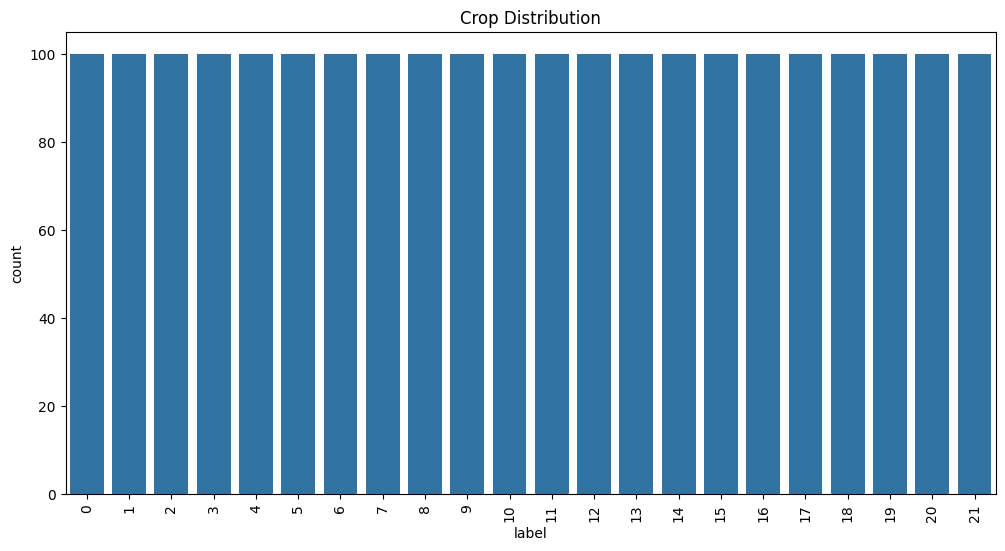

In [17]:
#Target Variable Distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.countplot(x='label', data=df)
plt.xticks(rotation=90)
plt.title("Crop Distribution")
plt.show()

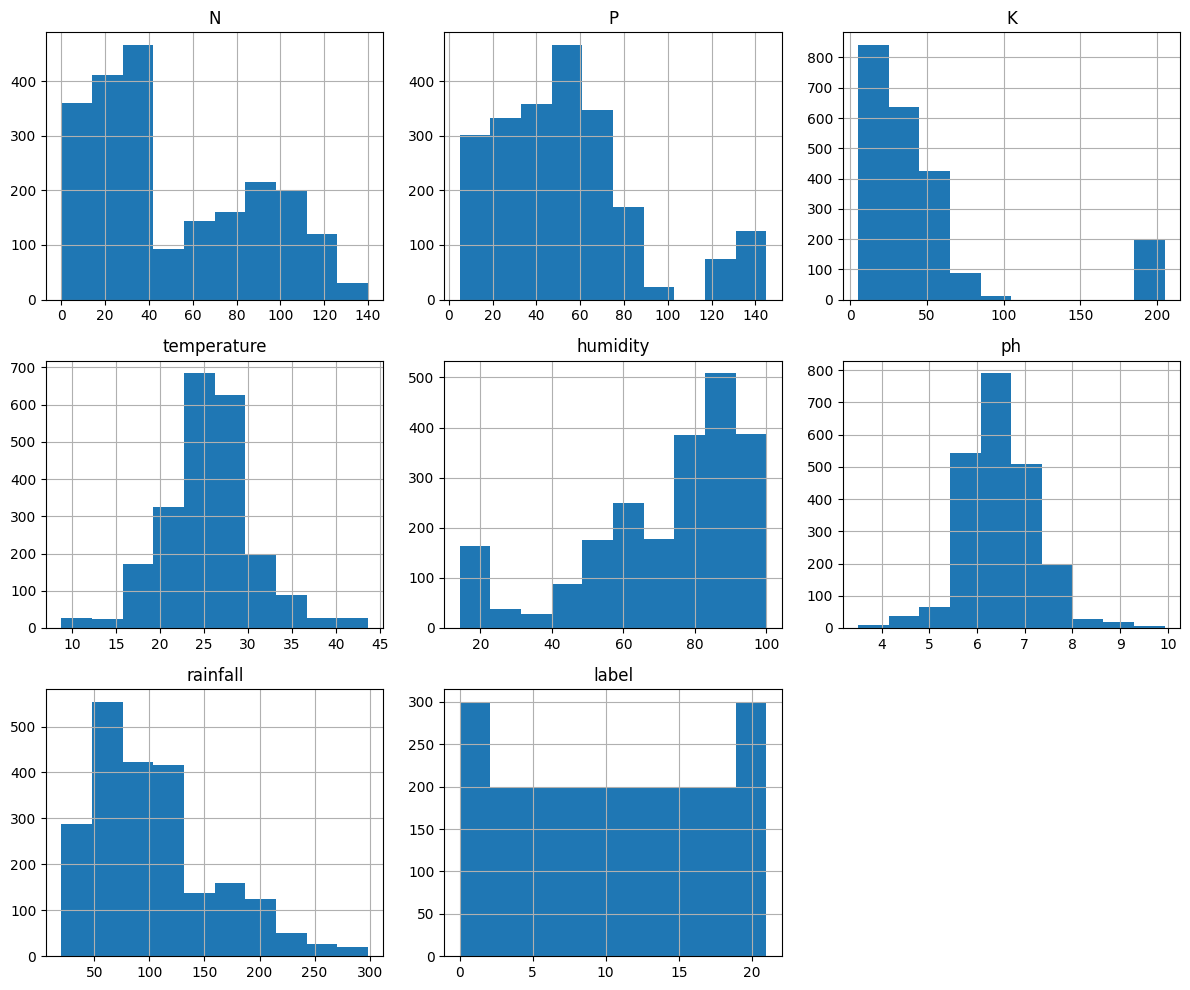

In [18]:
#Feature Distribution

df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

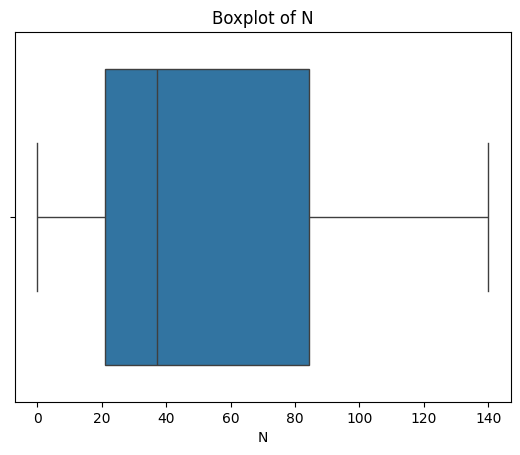

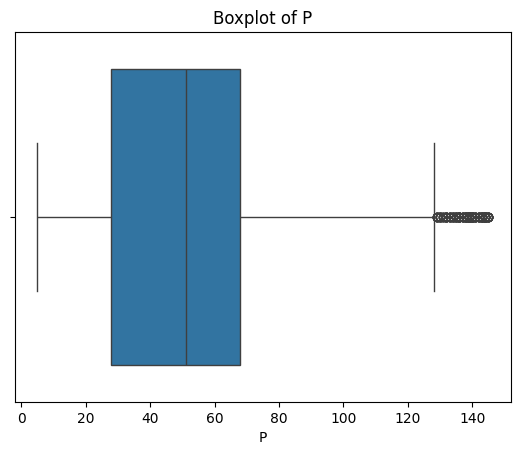

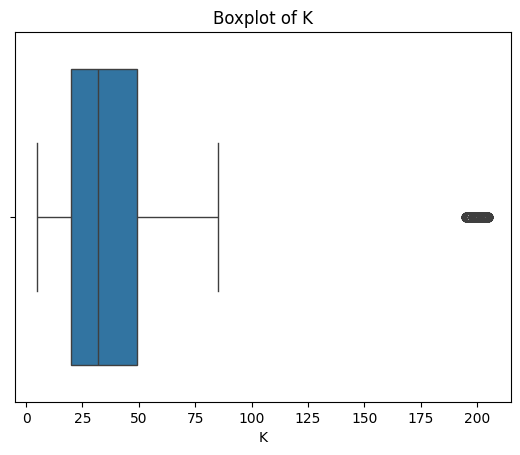

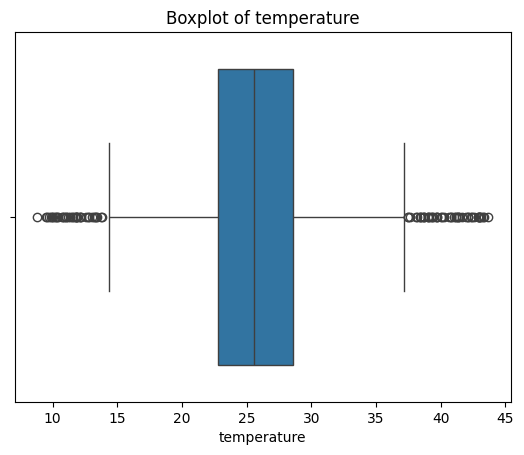

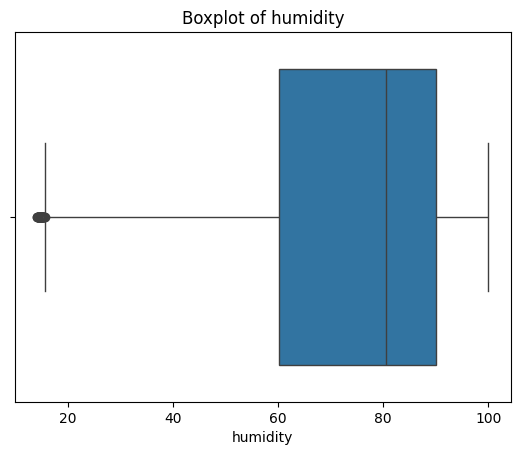

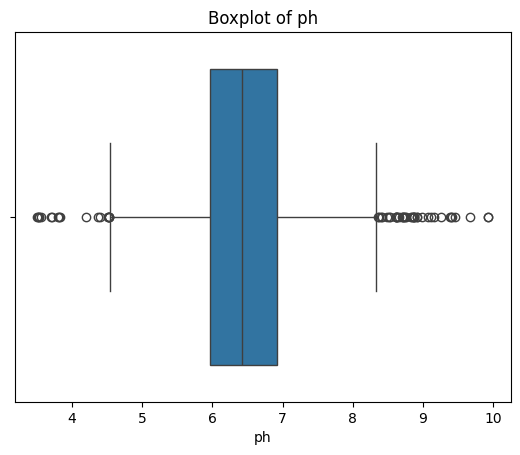

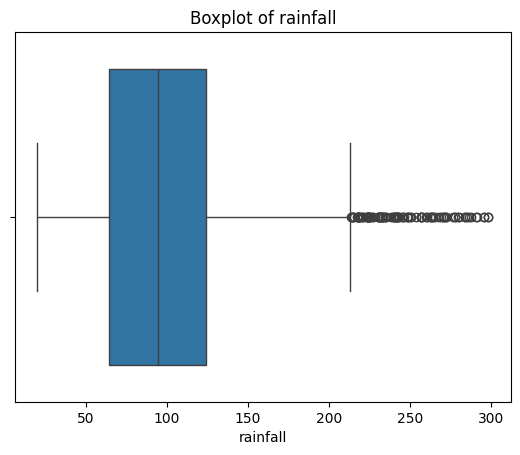

In [19]:
#Boxplots

for col in df.columns[:-1]:  # exclude label
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

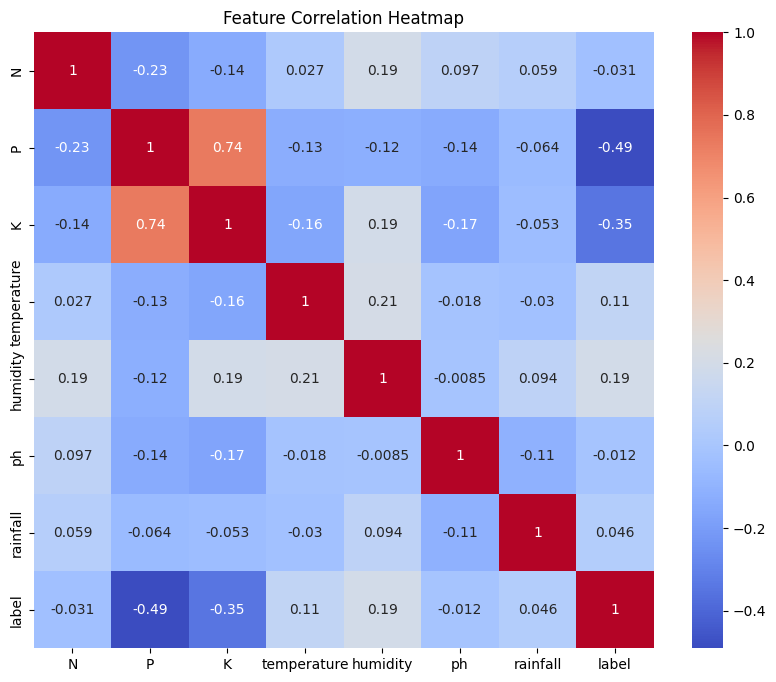

In [20]:
#Correlation Heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

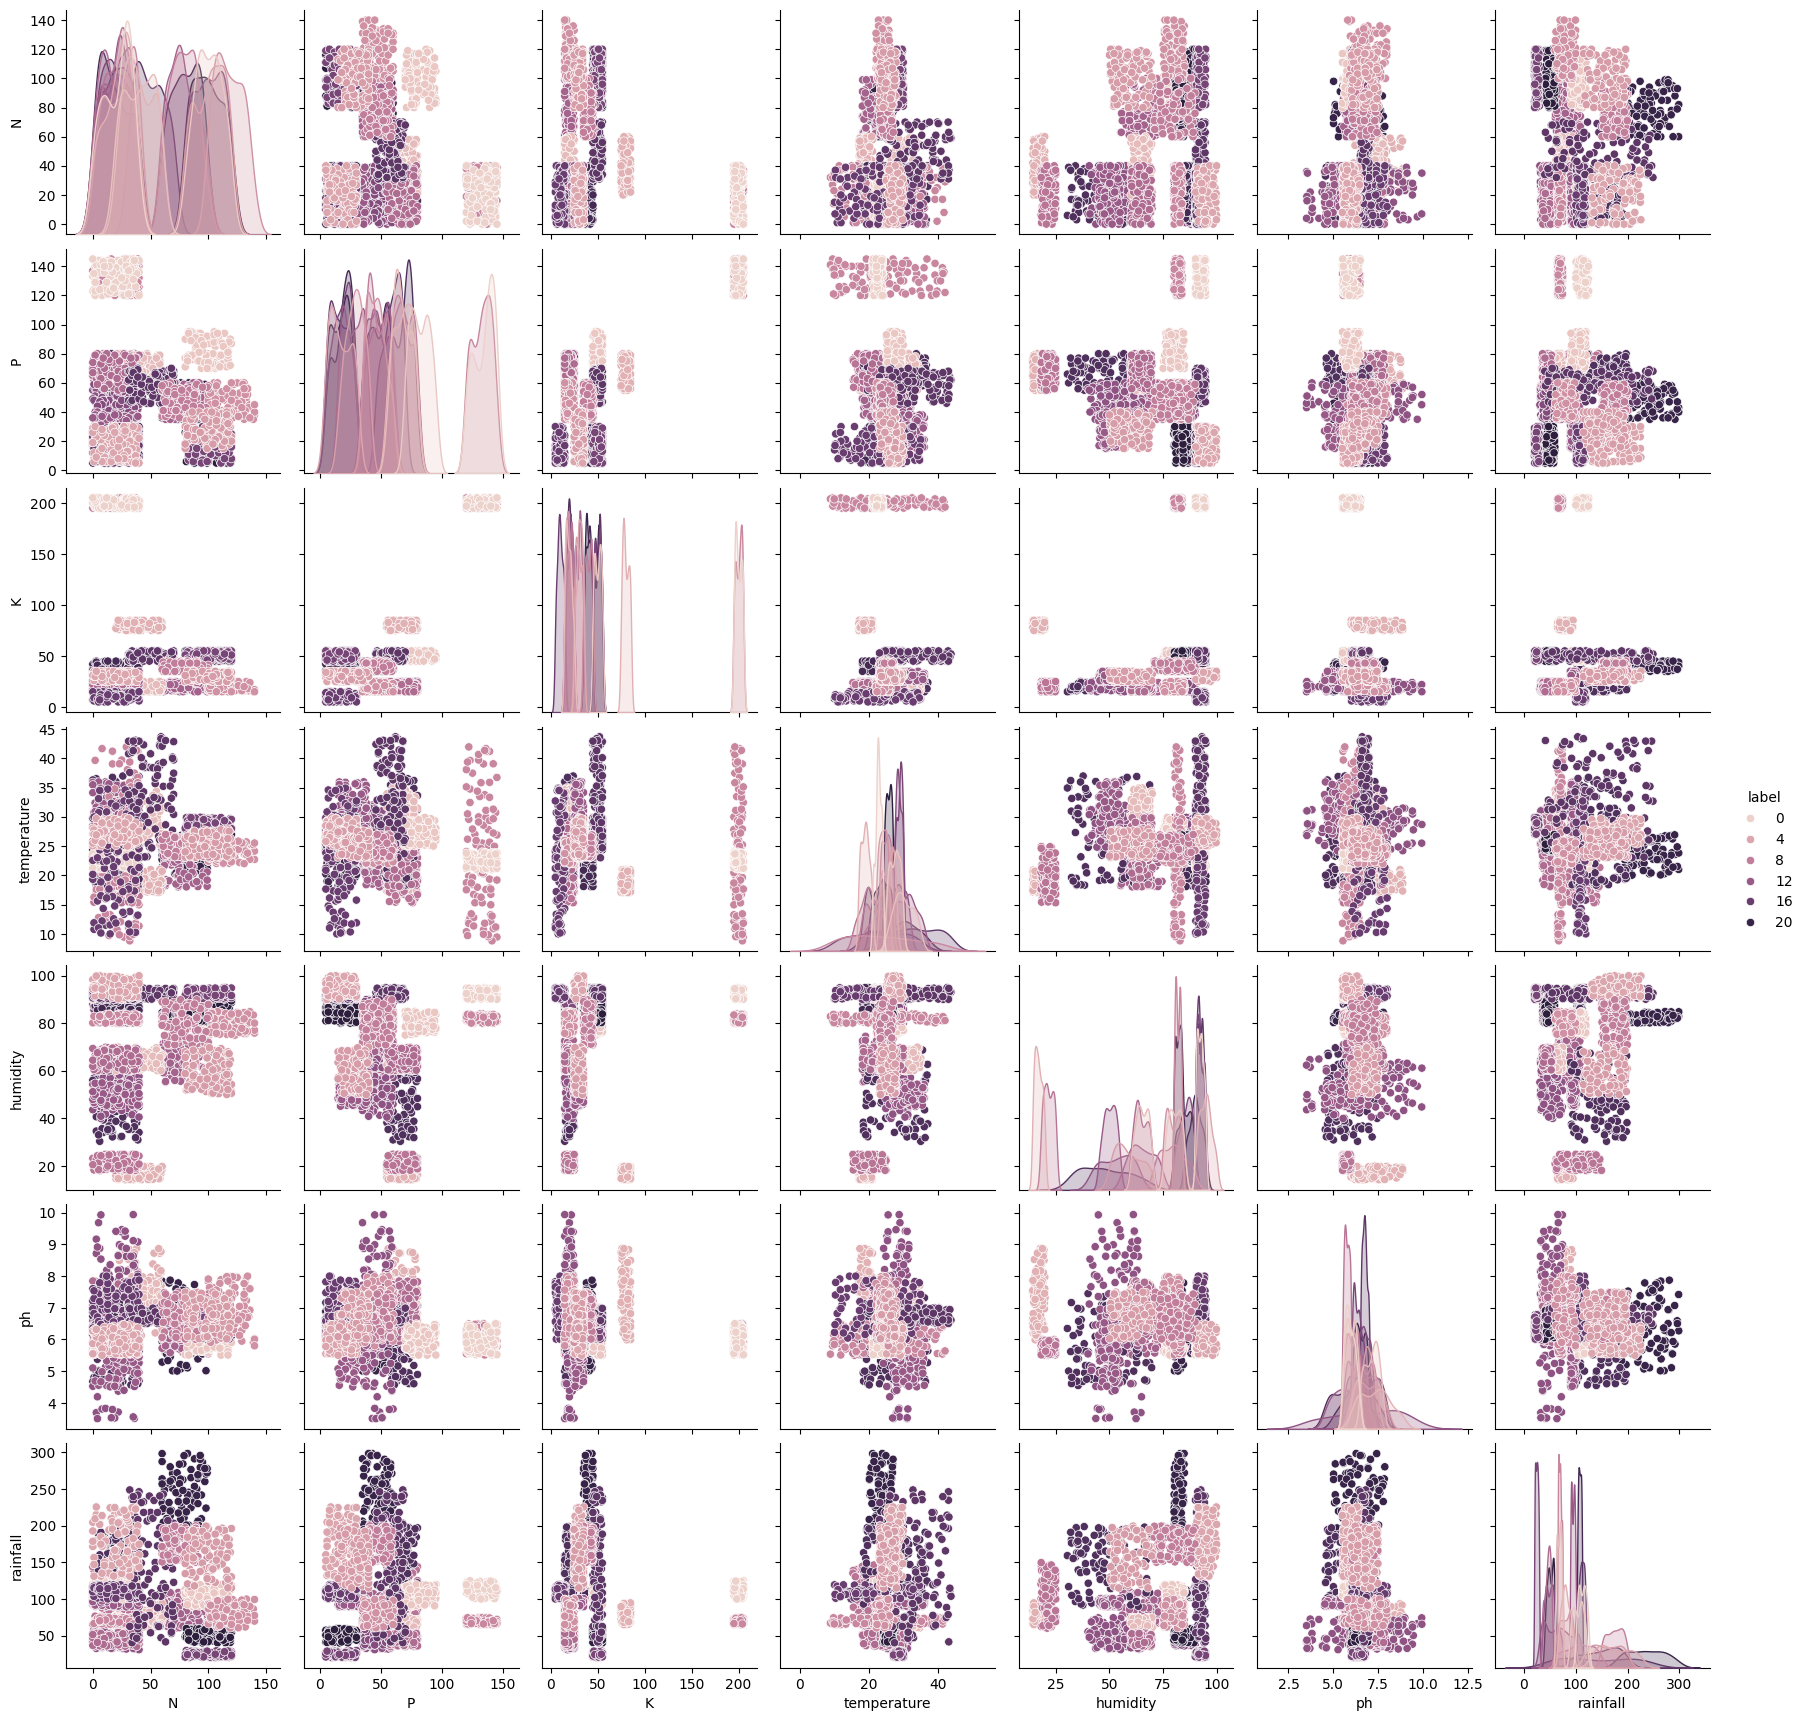

In [21]:
#Pairplot

sns.pairplot(df, hue='label')
plt.show()

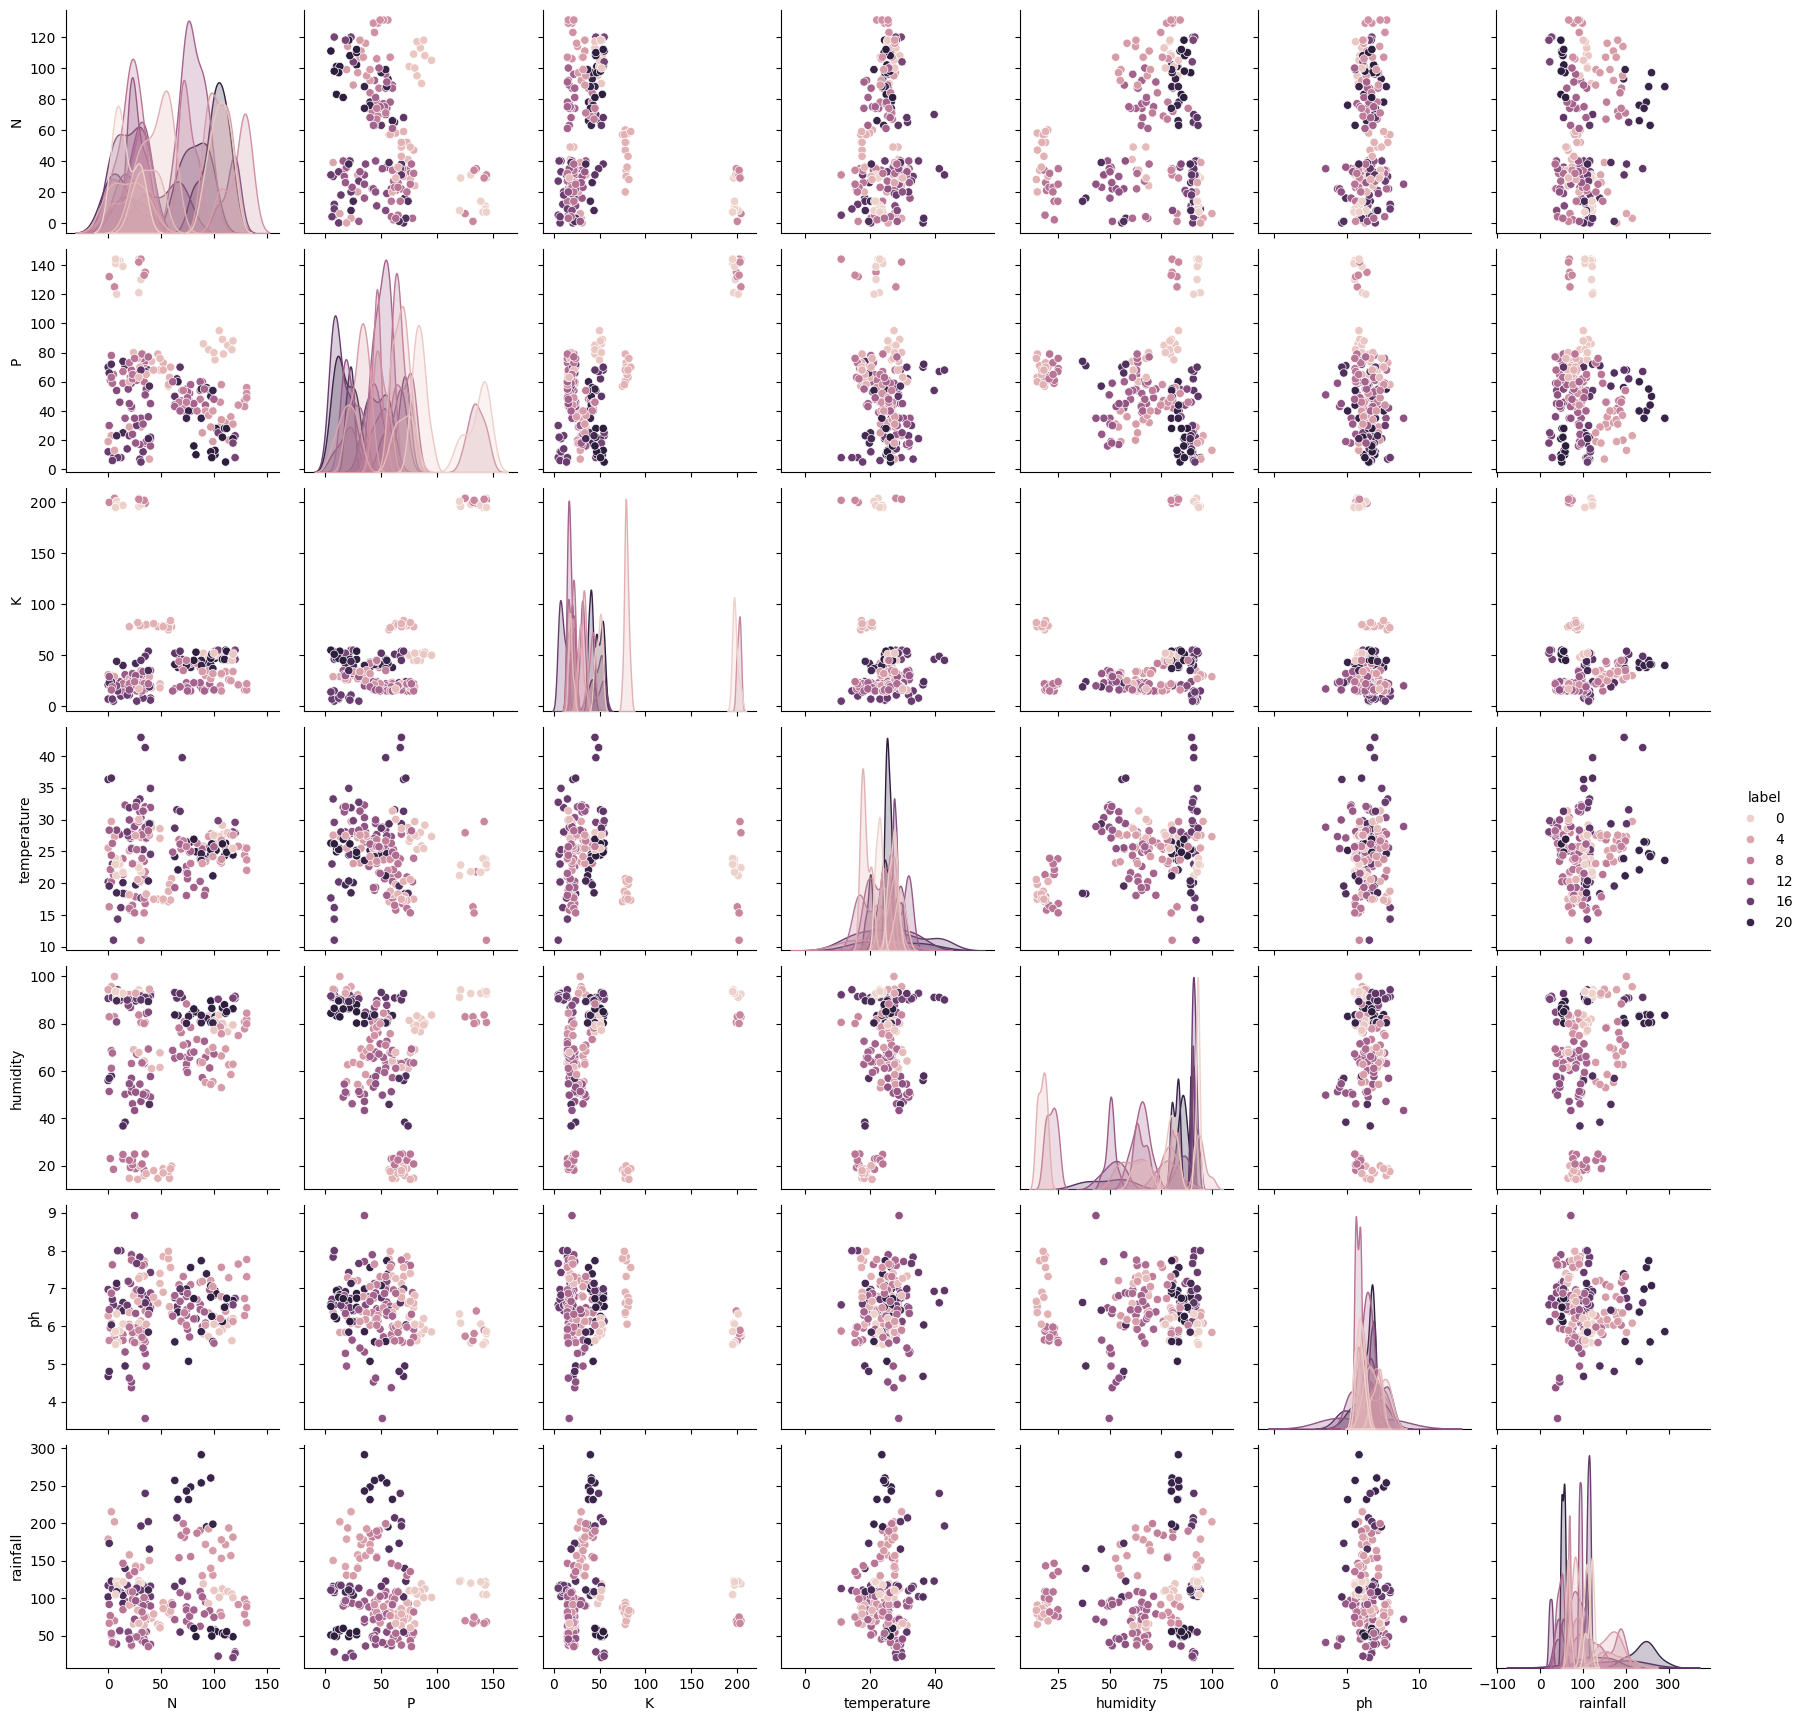

In [22]:
sns.pairplot(df.sample(200), hue='label')

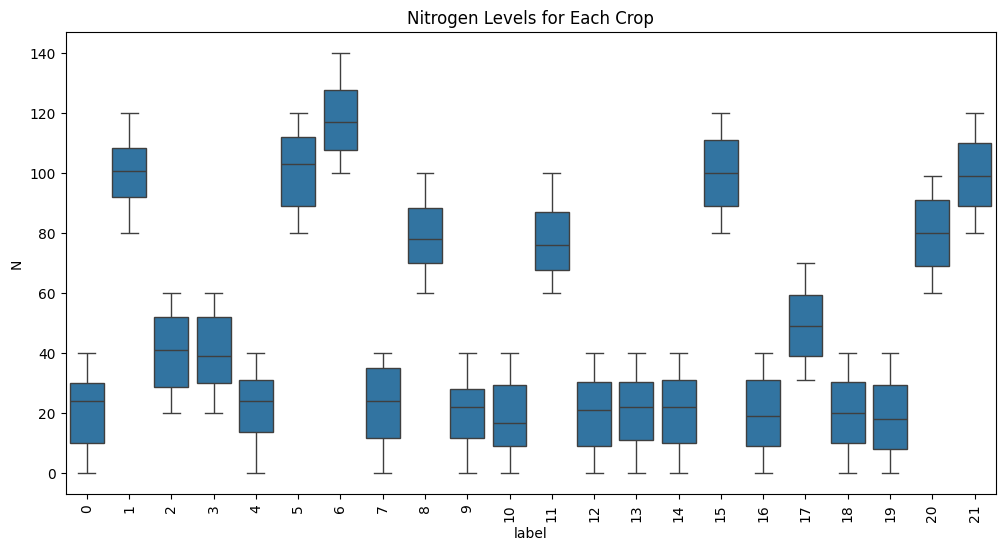

In [23]:
#Feature vs Target Analysis

plt.figure(figsize=(12,6))
sns.boxplot(x='label', y='N', data=df)
plt.xticks(rotation=90)
plt.title("Nitrogen Levels for Each Crop")
plt.show()

In [24]:
#Define Features (X) and Target (y)

X = df.drop('label', axis=1)
y = df['label']

In [25]:
#Split the Dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80% training, 20% testing
    random_state=42,    # ensures reproducibility
    stratify=y          # maintains class balance
)

In [26]:
#Verify the Split

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1760, 7)
X_test shape: (440, 7)
y_train shape: (1760,)
y_test shape: (440,)


In [27]:
#Check Class Distribution

print("Training set distribution:\n", y_train.value_counts(normalize=True))
print("\nTesting set distribution:\n", y_test.value_counts(normalize=True))

Training set distribution:
 label
16    0.045455
7     0.045455
9     0.045455
13    0.045455
6     0.045455
1     0.045455
10    0.045455
14    0.045455
5     0.045455
15    0.045455
0     0.045455
2     0.045455
18    0.045455
11    0.045455
20    0.045455
21    0.045455
8     0.045455
12    0.045455
19    0.045455
17    0.045455
4     0.045455
3     0.045455
Name: proportion, dtype: float64

Testing set distribution:
 label
16    0.045455
1     0.045455
6     0.045455
11    0.045455
3     0.045455
20    0.045455
2     0.045455
21    0.045455
19    0.045455
13    0.045455
7     0.045455
12    0.045455
0     0.045455
9     0.045455
8     0.045455
5     0.045455
4     0.045455
17    0.045455
10    0.045455
14    0.045455
18    0.045455
15    0.045455
Name: proportion, dtype: float64


In [28]:
#Import Models

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [29]:
#Train Models

#Decision Tree

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [30]:
#Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [31]:
#Predictions

dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

In [32]:
#Evaluate Models

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [33]:
#Decision Tree Evaluation

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("\nClassification Report:\n", classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.9795454545454545

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.80      0.89        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      0.95      0.95        20
           9       1.00      1.00      1.00        20
          10       0.86      0.90      0.88        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       0.86      0.95      0.90        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16 

In [34]:
#Random Forest Evaluation

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9954545454545455

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16 

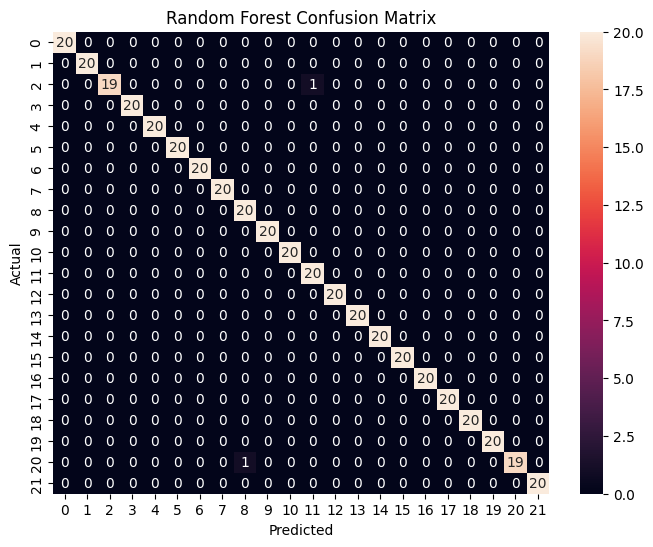

In [35]:
#Confusion Matrix

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
#Compare Models

dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Decision Tree Accuracy: {dt_acc:.4f}")
print(f"Random Forest Accuracy: {rf_acc:.4f}")

Decision Tree Accuracy: 0.9795
Random Forest Accuracy: 0.9955


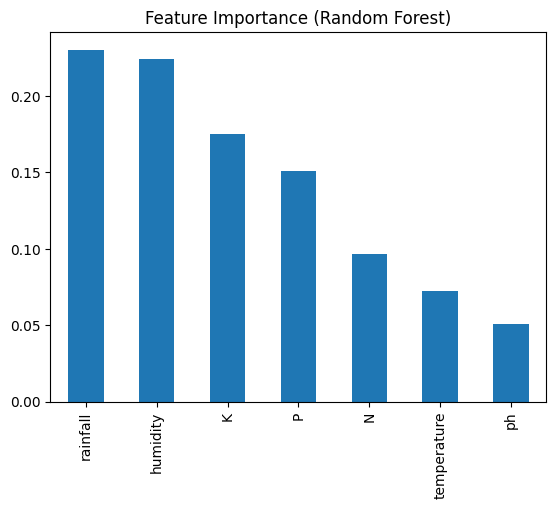

In [37]:
#Feature Importance

import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance (Random Forest)")
plt.show()

In [38]:
#Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

In [39]:
#Cross-Validation

from sklearn.model_selection import cross_val_score

rf_cv = cross_val_score(rf_model, X, y, cv=5)

print("Random Forest CV Scores:", rf_cv)
print("Mean CV Accuracy:", rf_cv.mean())

Random Forest CV Scores: [0.99772727 0.99318182 0.99772727 0.99545455 0.98863636]
Mean CV Accuracy: 0.9945454545454545


In [40]:
#Overfitting Check

train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 1.0
Testing Accuracy: 0.9954545454545455


In [41]:
#Model Comparison Table

import pandas as pd

results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [dt_acc, rf_acc]
})

print(results)

           Model  Accuracy
0  Decision Tree  0.979545
1  Random Forest  0.995455


In [42]:
#Define Prediction Function

def predict_crop(input_data, model, scaler, label_encoder):
    # Convert input to DataFrame
    import pandas as pd
    input_df = pd.DataFrame([input_data])

    # Scale input
    input_scaled = scaler.transform(input_df)

    # Predict
    prediction = model.predict(input_scaled)

    # Decode label
    crop = label_encoder.inverse_transform(prediction)

    return crop[0]

In [43]:
#Give Input Parameters

input_data = {
    'N': 90,
    'P': 42,
    'K': 43,
    'temperature': 20.5,
    'humidity': 82,
    'ph': 6.5,
    'rainfall': 202.9
}

In [44]:
#Predict Crop

result = predict_crop(input_data, rf_model, scaler, le)
print("Recommended Crop:", result)

Recommended Crop: kidneybeans


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [45]:
#Multiple Predictions

inputs = [
    {'N': 90, 'P': 42, 'K': 43, 'temperature': 20, 'humidity': 80, 'ph': 6.5, 'rainfall': 200},
    {'N': 20, 'P': 30, 'K': 40, 'temperature': 30, 'humidity': 60, 'ph': 7.0, 'rainfall': 100}
]

for data in inputs:
    print(predict_crop(data, rf_model, scaler, le))

kidneybeans
kidneybeans


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [46]:
#Build UI (Streamlit)

# Install Streamlit
!pip install streamlit

# streamlit app example
import streamlit as st

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 90.1 MB/s eta 0:00:00


In [47]:
#Save Model

import joblib

joblib.dump(rf_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [48]:
# Modularize Code

def preprocess_input(data):
    ...

def predict(data):
    ...


Deep Learning Model (ANN)


In [49]:
#Import Libraries

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [50]:
#Build Neural Network

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(set(y)), activation='softmax')  # output layer
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
#Compile Model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [52]:
#Train Model

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5028 - loss: 3.0245 - val_accuracy: 0.8551 - val_loss: 0.4737
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8814 - loss: 0.4159 - val_accuracy: 0.9006 - val_loss: 0.3038
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9119 - loss: 0.2839 - val_accuracy: 0.9091 - val_loss: 0.2574
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9261 - loss: 0.2408 - val_accuracy: 0.9119 - val_loss: 0.2337
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9361 - loss: 0.1873 - val_accuracy: 0.9460 - val_loss: 0.1766
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9283 - loss: 0.1921 - val_accuracy: 0.9375 - val_loss: 0.1834
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9325 - loss: 0.1788 - val_accuracy: 0.9517 - val_loss: 0.1645
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9545 - loss: 0.1356 - val_accuracy: 0.9403 - val_loss:

In [53]:
#Evaluate Model

loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9659 - loss: 0.1121  
Test Accuracy: 0.9659090638160706


In [54]:
#Predictions

predictions = model.predict(X_test)
pred_classes = predictions.argmax(axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


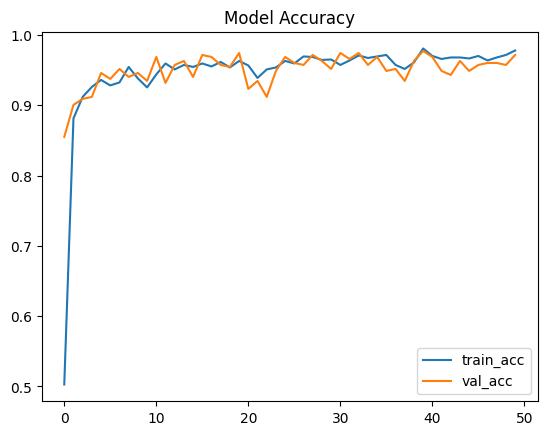

In [55]:
#Plot Training Performance

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Model Accuracy")
plt.show()

In [56]:
#Improve the Mode
#Add Dropout (reduce overfitting)

layers.Dropout(0.3)

<Dropout name=dropout, built=True>

In [58]:
layers.Dropout(0.3)

#Early Stopping

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=5)

model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, callbacks=[early_stop])

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9673 - loss: 0.0755 - val_accuracy: 0.9688 - val_loss: 0.1051
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9744 - loss: 0.0730 - val_accuracy: 0.9602 - val_loss: 0.1295
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9773 - loss: 0.0605 - val_accuracy: 0.9688 - val_loss: 0.1198
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9716 - loss: 0.0755 - val_accuracy: 0.9347 - val_loss: 0.1827
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9695 - loss: 0.0708 - val_accuracy: 0.9631 - val_loss: 0.1130
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9688 - loss: 0.0896 - val_accuracy: 0.9574 - val_loss: 0.0883
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9780 - loss: 0.0594 - val_accuracy: 0.9602 - val_loss: 0.0994
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9673 - loss: 0.0678 - val_accuracy: 0.9631 - val_loss:

In [59]:
#Compare with Random Forest

from sklearn.metrics import accuracy_score

print("RF Accuracy:", rf_acc)
print("DL Accuracy:", accuracy)

RF Accuracy: 0.9954545454545455
DL Accuracy: 0.9659090638160706


In [77]:
import requests

API_KEY = "6ba29dc3cec671f8c2fd41b3aeb630a4"  # replace with valid key
city = "Thiruvananthapuram"

url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"

response = requests.get(url)
data = response.json()

# Debug response
print("API Response:", data)

# Safe extraction
if response.status_code == 200 and 'main' in data:
    temperature = data['main']['temp']
    humidity = data['main']['humidity']

    rainfall = data.get('rain', {}).get('1h', 0)

    print("Temperature:", temperature)
    print("Humidity:", humidity)
    print("Rainfall:", rainfall)

else:
    print("Error:", data.get('message', 'Unknown error'))

API Response: {'cod': 401, 'message': 'Invalid API key. Please see https://openweathermap.org/faq#error401 for more info.'}
Error: Invalid API key. Please see https://openweathermap.org/faq#error401 for more info.


In [78]:
#Handle Rainfall

rainfall = data.get('rain', {}).get('1h', 0)  # rainfall in last 1 hour

In [79]:
#Combine API Data with Model Input

input_data = {
    'N': 90,
    'P': 42,
    'K': 43,
    'temperature': temperature,
    'humidity': humidity,
    'ph': 6.5,
    'rainfall': rainfall
}

In [80]:
#Predict Crop Automatically

result = predict_crop(input_data, rf_model, scaler, le)
print("Recommended Crop:", result)

Recommended Crop: orange


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [81]:
#Improve Accuracy with Location

lat = 8.5241
lon = 76.9366

url = f"http://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={API_KEY}&units=metric"